In [5]:
import xarray as xr
import rioxarray as rxr

# Load hyperspectral cube (lazy loading)
cube = rxr.open_rasterio(
    "F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081129T171509_V02_RDN.IMG",
    chunks={"x": 512, "y": 512}
)

print(cube)

<xarray.DataArray (band: 85, y: 5636, x: 304)> Size: 583MB
dask.array<open_rasterio-e1d20e4f5c68c27df9f87a8d4a9f46ef<this-array>, shape=(85, 5636, 304), dtype=float32, chunksize=(85, 512, 304), chunktype=numpy.ndarray>
Coordinates:
    wavelength   (band) float64 680B dask.array<chunksize=(85,), meta=np.ndarray>
  * band         (band) int64 680B 1 2 3 4 5 6 7 8 9 ... 78 79 80 81 82 83 84 85
  * x            (x) float64 2kB 0.5 1.5 2.5 3.5 4.5 ... 300.5 301.5 302.5 303.5
  * y            (y) float64 45kB 0.5 1.5 2.5 ... 5.634e+03 5.634e+03 5.636e+03
    spatial_ref  int64 8B 0
Attributes: (12/107)
    Band_1:                    460.99
    Band_2:                    500.92
    Band_3:                    540.84
    Band_4:                    580.76
    Band_5:                    620.69
    Band_6:                    660.61
    ...                        ...
    byte_order:                0
    description:               M3 Global Mode Calibrated Data version r;Raw i...
    target_wavelen

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rioxarray\_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


In [6]:
print(cube.shape)   # (bands, y, x)
print(cube.dtype)

(85, 5636, 304)
float32


In [7]:
cube_small = cube[:, :2000, :200]

In [8]:
cube_small = cube_small.where(cube_small != 0)

In [9]:
print("Cube small shape:", cube_small.shape)
print("Min:", float(cube_small.min()))
print("Max:", float(cube_small.max()))

Cube small shape: (85, 2000, 200)
Min: 0.9355745911598206
Max: 192.31517028808594


In [10]:
# Example indices (you will refine later using wavelengths)
band_20 = cube_small[20]
band_40 = cube_small[40]
band_60 = cube_small[60]

ratio1 = band_40 / band_20
ratio2 = band_60 / band_40

In [11]:
slope = band_60 - band_20

In [ ]:
import numpy as np

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Check if X has samples before scaling
if X.shape[0] > 0:
	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(X)
else:
	print(f"Warning: X is empty with shape {X.shape}. Adjust crop indices in earlier cells.")
	X_scaled = X

In [14]:
print(cube_small.shape)

(85, 2000, 200)


In [15]:
# 1. Correct crop
cube_small = cube[:, 1000:2000, 50:250]

print("Shape:", cube_small.shape)

# 2. DO NOT over-clean yet
# cube_small = cube_small.where(cube_small > 0)  ❌ remove for now

# 3. Features (safe division)
band_20 = cube_small[20]
band_40 = cube_small[40]
band_60 = cube_small[60]

ratio1 = band_40 / (band_20 + 1e-6)
ratio2 = band_60 / (band_40 + 1e-6)
slope = band_60 - band_20

# 4. Stack
features = xr.concat([ratio1, ratio2, slope], dim="feature")

# 5. Convert
X = features.values.reshape(features.shape[0], -1).T

print("X shape:", X.shape)

# 6. Clean
import numpy as np
X = np.nan_to_num(X)

# 7. Scale
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# 8. Cluster
from sklearn.cluster import MiniBatchKMeans
labels = MiniBatchKMeans(n_clusters=4).fit_predict(X_scaled)

Shape: (85, 1000, 200)
X shape: (200000, 3)


c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [16]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=4, batch_size=10000)
labels = kmeans.fit_predict(X_scaled)

In [17]:
labels_img = labels.reshape(1000, 200)

In [18]:
def extract_wavelengths(hdr_path):
    with open(hdr_path, 'r') as f:
        text = f.read()
    
    start = text.find("wavelength")
    start = text.find("{", start)
    end = text.find("}", start)
    
    wl_text = text[start+1:end]
    
    wavelengths = [float(w.strip()) for w in wl_text.split(",")]
    return wavelengths

wavelengths = extract_wavelengths("F:\SATELLITE ANALYSIS\Lunar\spectral data\M3G20081129T171509_V02_RDN.HDR")

print(len(wavelengths))
print(wavelengths[:10])

85
[460.99, 500.92, 540.84, 580.76, 620.69, 660.61, 700.54, 730.48, 750.44, 770.4]


In [19]:
print(len(wavelengths))

85


In [20]:
import numpy as np

def find_band(target):
    wavelengths_np = np.array(wavelengths)
    idx = np.abs(wavelengths_np - target).argmin()
    return idx, wavelengths_np[idx]

In [21]:
b_750, wl_750 = find_band(750)
b_1000, wl_1000 = find_band(1000)
b_1500, wl_1500 = find_band(1500)
b_2000, wl_2000 = find_band(2000)

print("750nm:", b_750, wl_750)
print("1000nm:", b_1000, wl_1000)
print("1500nm:", b_1500, wl_1500)
print("2000nm:", b_2000, wl_2000)

750nm: 8 750.44
1000nm: 21 1009.95
1500nm: 46 1508.99
2000nm: 60 2018.02


In [22]:
b_1800, wl_1800 = find_band(1800)

In [23]:
R750 = cube_small[b_750]
R1000 = cube_small[b_1000]
R1500 = cube_small[b_1500]
R2000 = cube_small[b_2000]

In [24]:
R750  = cube_small[8]
R1000 = cube_small[21]
R1500 = cube_small[46]
R2000 = cube_small[60]

In [25]:
BD1000 = 1 - (R1000 / ((R750 + R1500) / 2 + 1e-6))

In [26]:
BD2000 = 1 - (R2000 / (R1500 + 1e-6))

In [27]:
OLIVINE = R1000 / (R750 + 1e-6)

In [28]:
SLOPE = R1500 - R750

In [29]:
import numpy as np

BD1000 = np.clip(BD1000, -1, 1)
BD2000 = np.clip(BD2000, -1, 1)
OLIVINE = np.clip(OLIVINE, 0, 5)
SLOPE = np.clip(SLOPE, -100, 100)

In [30]:
import xarray as xr

features = xr.concat(
    [BD1000, BD2000, OLIVINE, SLOPE],
    dim="feature"
)
features = xr.concat(
    [BD1000, BD2000, OLIVINE, SLOPE],
    dim="feature"
)

In [31]:
print(features.dims)

('feature', 'y', 'x')


In [32]:
X = features.values.reshape(features.shape[0], -1).T
X = np.nan_to_num(X)

In [33]:
X_scaled = StandardScaler().fit_transform(X)
labels = MiniBatchKMeans(n_clusters=4).fit_predict(X_scaled)

In [34]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [35]:
MiniBatchKMeans(n_clusters=4, batch_size=10000)

,n_clusters,4
,init,'k-means++'
,max_iter,100
,batch_size,10000
,verbose,0
,compute_labels,True
,random_state,None
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


In [36]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

In [37]:
X = features.values.reshape(features.shape[0], -1).T
X = np.nan_to_num(X)

In [38]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

In [39]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=4, batch_size=10000)
labels = kmeans.fit_predict(X_scaled)

In [40]:
labels_img = labels.reshape(features.shape[1], features.shape[2])

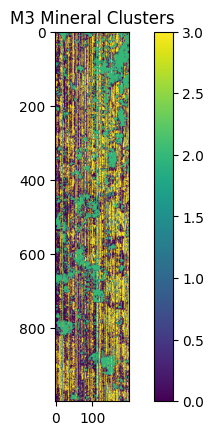

In [41]:
import matplotlib.pyplot as plt

plt.imshow(labels_img, cmap='viridis')
plt.colorbar()
plt.title("M3 Mineral Clusters")
plt.show()

In [42]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

In [43]:
with rasterio.open("F:\SATELLITE ANALYSIS\Lunar\MINI-RF\S1A_IW_GRDH_20250105_Orb_Subset_tnr_Cal_glcm_Sigma0_VH_Entropy.tif") as sar:
    sar_data = sar.read(1)
    sar_transform = sar.transform
    sar_crs = sar.crs
    sar_shape = sar_data.shape

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [45]:
print(BD1000.shape)
print(sar_data.shape)

(1000, 200)
(8890, 18271)


In [46]:
from skimage.transform import resize

m3_resampled = resize(
    BD1000.values,
    sar_data.shape,
    order=1,
    preserve_range=True
)

In [47]:
from skimage.transform import resize

m3_resampled = resize(
    BD1000.values,
    sar_data.shape,
    order=1,
    preserve_range=True
)

In [49]:
from skimage.transform import resize

m3_resampled_bd1000 = resize(BD1000.values, sar_data.shape, order=1, preserve_range=True)
m3_resampled_bd2000 = resize(BD2000.values, sar_data.shape, order=1, preserve_range=True)
m3_resampled_olivine = resize(OLIVINE.values, sar_data.shape, order=1, preserve_range=True)
m3_resampled_slope = resize(SLOPE.values, sar_data.shape, order=1, preserve_range=True)

In [50]:
print(m3_resampled_bd1000.shape)
print(sar_data.shape)

(8890, 18271)
(8890, 18271)


In [51]:
import numpy as np

X_m3 = np.stack([
    m3_resampled_bd1000,
    m3_resampled_bd2000,
    m3_resampled_olivine,
    m3_resampled_slope
], axis=-1)

In [52]:
X_m3 = X_m3.reshape(-1, 4)

In [55]:
import numpy as np

sar_norm = (sar_data - sar_data.min()) / (sar_data.max() - sar_data.min() + 1e-6)
sar_norm = (sar_norm * 255).astype(np.uint8)

In [56]:
from skimage.feature import graycomatrix, graycoprops

window_size = 5
pad = window_size // 2

height, width = sar_norm.shape

contrast = np.zeros((height, width))
entropy = np.zeros((height, width))
homogeneity = np.zeros((height, width))

In [63]:
sar_norm = sar_norm[:500, :500]

In [64]:
block_size = 10

h, w = sar_norm.shape

contrast = []
homogeneity = []
entropy = []

for i in range(0, h, block_size):
    for j in range(0, w, block_size):
        patch = sar_norm[i:i+block_size, j:j+block_size]

        if patch.shape[0] < block_size or patch.shape[1] < block_size:
            continue

        glcm = graycomatrix(patch, [1], [0], levels=256, symmetric=True, normed=True)

        contrast.append(graycoprops(glcm, 'contrast')[0, 0])
        homogeneity.append(graycoprops(glcm, 'homogeneity')[0, 0])

        p = glcm[:, :, 0, 0]
        p = p[p > 0]
        entropy.append(-np.sum(p * np.log(p)))

In [65]:
X_sar = np.stack([contrast, homogeneity, entropy], axis=1)

In [69]:
sar_features = np.stack([contrast, entropy,     homogeneity], axis=-1)
X_sar = sar_features.reshape(-1, 3)

In [71]:
print("Hello, World!")

Hello, World!


In [72]:
print(X_sar.shape)
print(X_m3.shape)

(162429190, 3)
(162429190, 4)


In [73]:
min_pixels = min(X_sar.shape[0], X_m3.shape[0])

X_sar = X_sar[:min_pixels]
X_m3 = X_m3[:min_pixels]

In [75]:
import numpy as np

n_samples = 100000  # 100k pixels (safe)

indices = np.random.choice(X_sar.shape[0], n_samples, replace=False)

X_sar_sample = X_sar[indices]
X_m3_sample = X_m3[indices]

In [76]:
X_sar_sample = np.nan_to_num(X_sar_sample)
X_m3_sample = np.nan_to_num(X_m3_sample)

In [77]:
X_fused = np.hstack([X_sar_sample, X_m3_sample])

In [78]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=5)
labels = kmeans.fit_predict(X_fused)

c:\Users\karna\miniconda3\envs\sar_env\lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


In [80]:
labels_full = kmeans.predict(X_fused)

In [81]:
import os

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"

In [82]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(
    n_clusters=5,
    batch_size=10000,   # already good
    n_init=10
)

In [83]:
import warnings
warnings.filterwarnings("ignore")

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(contrast, cmap='gray')
plt.title("SAR Texture (Contrast)")
plt.colorbar()
plt.show()

MemoryError: Unable to allocate 155. MiB for an array with shape (8890, 18271) and data type bool

<Figure size 600x600 with 2 Axes>

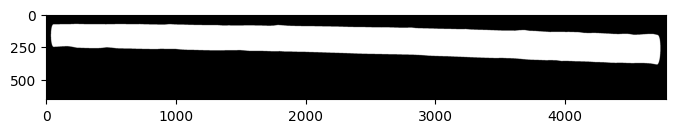

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))   # smaller figure
plt.imshow(data, cmap='gray')
plt.show()

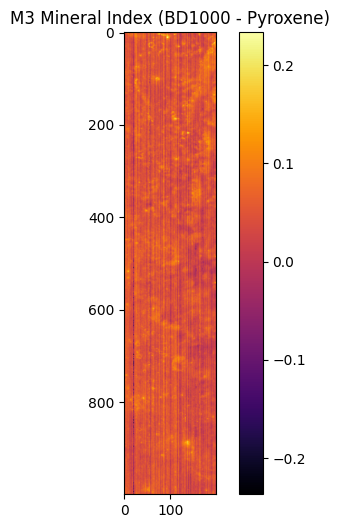

In [85]:
plt.figure(figsize=(6,6))
plt.imshow(BD1000, cmap='inferno')
plt.title("M3 Mineral Index (BD1000 - Pyroxene)")
plt.colorbar()
plt.show()

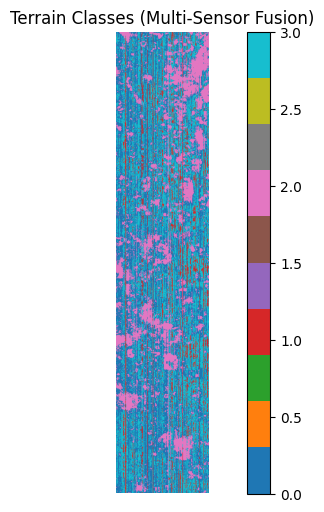

In [87]:
plt.figure(figsize=(10, 6))
plt.imshow(labels_img, cmap='tab10')
plt.colorbar()
plt.title("Terrain Classes (Multi-Sensor Fusion)")
plt.axis('off')
plt.show()

In [91]:
labels_full
height, width

(8890, 18271)

In [93]:
plt.figure(figsize=(8,6))
plt.imshow(labels_full.reshape(height, width), cmap='viridis')
plt.title("Fused Terrain Classification (SAR + M3)")
plt.colorbar()
plt.show()

ValueError: cannot reshape array of size 100000 into shape (8890,18271)

<Figure size 800x600 with 0 Axes>

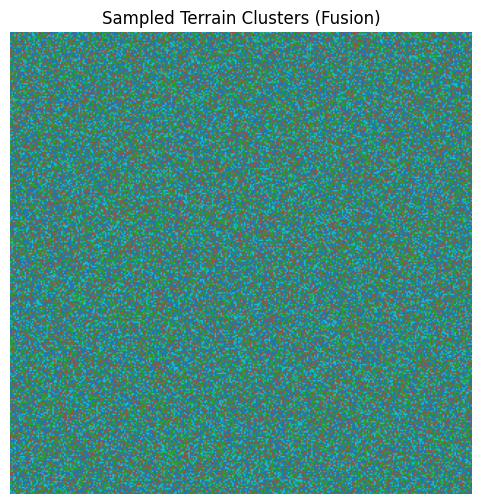

In [100]:
import matplotlib.pyplot as plt

# Assume square visualization
n = int(np.sqrt(len(labels)))  # labels = 100k

labels_vis = labels[:n*n].reshape(n, n)

plt.figure(figsize=(6,6))
plt.imshow(labels_vis, cmap='tab10')
plt.title("Sampled Terrain Clusters (Fusion)")
plt.axis('off')
plt.show()

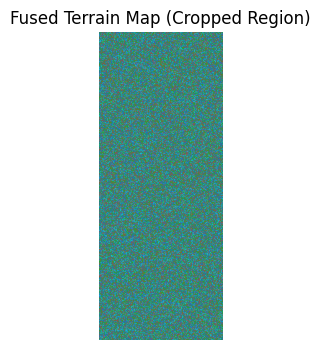

In [101]:
h_small, w_small = 500, 200

labels_small = labels_full[:h_small * w_small]

labels_img = labels_small.reshape(h_small, w_small)

plt.figure(figsize=(8,4))
plt.imshow(labels_img, cmap='tab10')
plt.title("Fused Terrain Map (Cropped Region)")
plt.axis('off')
plt.show()

In [103]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=5, batch_size=10000)

kmeans.fit(X_fused)   # ⚠️ THIS IS REQUIRED

,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,10000
,verbose,0
,compute_labels,True
,random_state,None
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


In [104]:
chunk_size = 50000
labels_full = []

for i in range(0, X_fused.shape[0], chunk_size):
    chunk = X_fused[i:i+chunk_size]
    pred = kmeans.predict(chunk)
    labels_full.append(pred)

labels_full = np.concatenate(labels_full)

In [120]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=5, batch_size=10000)

# Train on sample
kmeans.fit(X_fused)

# Predict on same sample (for visualization)
labels = kmeans.predict(X_fused)

In [121]:
import plotly.express as px

n = int(np.sqrt(len(labels)))
labels_vis = labels[:n*n].reshape(n, n)

fig = px.imshow(labels_vis, color_continuous_scale='Viridis')

fig.update_layout(title="Fused Terrain (Interactive)")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAABAA' ... 'ABAAAAAAAAAAAAAAAAAAAAAAAAAA=='),
                    'dtype': 'i4',
                    'shape': '316, 316'}}],
    'layout': {'coloraxis': {'colorscale': [[0.0, '#440154'], [0.1111111111111111,
                                            '#482878'], [0.2222222222222222,
                                            '#3e4989'], [0.3333333333333333,
                                            '#31688e'], [0.4444444444444444,
                                            '#26828e'], [0.5555555555555556,
                                            '#1f9e89'], [0.6666666666666666,
                                            '#35b779'], [0.7777777777777778,
                                            '#6ece58'], [0.8888888888888888,
                                            '#b5de2b'], [1.0, '#fde725']]},
               'margin': {'t': 60},
               'template': '...',
               'title': {'text': 'Fused Terrain (Interactive)'},
               'xaxis': {'anchor': 'y', 'constrain': 'domain', 'domain': [0.0, 1.0], 'scaleanchor': 'y'},
               'yaxis': {'anchor': 'x', 'autorange': 'reversed', 'constrain': 'domain', 'domain': [0.0, 1.0]}}
})

In [122]:
fig.write_html("fused_map.html")

In [123]:
import plotly.io as pio
pio.renderers.default = "browser"

In [124]:
import plotly.express as px

n = int(np.sqrt(len(labels)))
labels_vis = labels[:n*n].reshape(n, n)

fig = px.imshow(labels_vis, color_continuous_scale='Viridis')
fig.update_layout(title="Fused Terrain (Interactive)")

In [125]:
fig.write_html("fused_map.html")


(np.float64(-0.5), np.float64(199.5), np.float64(499.5), np.float64(-0.5))

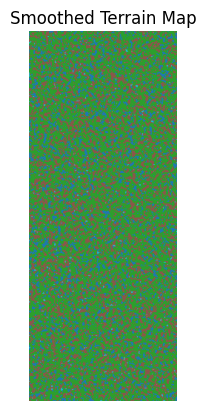

In [127]:
from scipy.ndimage import median_filter

labels_img_smooth = median_filter(labels_img, size=3)

plt.imshow(labels_img_smooth, cmap='tab10')
plt.title("Smoothed Terrain Map")
plt.axis('off')

In [128]:
kmeans = MiniBatchKMeans(n_clusters=3)

(np.float64(-0.5), np.float64(315.5), np.float64(315.5), np.float64(-0.5))

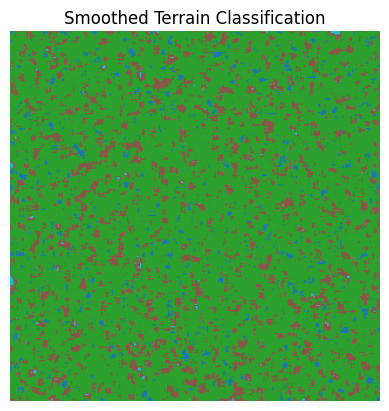

In [129]:
from scipy.ndimage import median_filter

labels_img_smooth = median_filter(labels_vis, size=5)

plt.imshow(labels_img_smooth, cmap='tab10')
plt.title("Smoothed Terrain Classification")
plt.axis('off')